In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Đọc dữ liệu
df = pd.read_json("chat_log.json", encoding="utf-8")
df.head

,role,content,time
0,user,"Xin chào. Em là Izumi Kurose, học sinh lớp 1-C...",2026-09-04 10:56:19
1,assistant,"*ngồi tựa người vào tường, tay cầm ly trà sữa,...",2026-09-04 10:56:23
2,user,Chị Yokoyama học lớp trên nào vậy. Trước em có...,2026-09-04 10:58:28
3,assistant,"*ngửa đầu ra sau, cười nhẹ*\n\nLớp 2-B. *nhìn ...",2026-09-04 10:58:32
4,user,"Vaang... mà em là con trai mà, em chưa kịp cắt...",2026-09-04 11:00:58


In [3]:
# Xem thông tin của Data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   role     6 non-null      str  
 1   content  6 non-null      str  
 2   time     6 non-null      str  
dtypes: str(3)
memory usage: 276.0 bytes


In [4]:
# Thêm cột "số ký tự"
df["char_count"] = df["content"].apply(len)

In [6]:
df[["role", "char_count"]]

,role,char_count
0,user,133
1,assistant,887
2,user,211
3,assistant,742
4,user,161
5,assistant,1056


In [7]:
# Thống kê theo vai trò
summary = df.groupby("role")["char_count"].agg(["count", "mean", "sum"])

In [8]:
summary

,count,mean,sum
role,,,
assistant,3,895.000000,2685
user,3,168.333333,505


In [12]:
# Nhãn dán cho từng vai trò
role_labels = {
    "user": "Bạn",
    "assistant": "AI (Ishimi)"
}

In [13]:
df["role_label"] = df["role"].map(role_labels)

In [14]:
df.head()

,role,content,time,char_count,role_label
0,user,"Xin chào. Em là Izumi Kurose, học sinh lớp 1-C...",2026-09-04 10:56:19,133,Bạn
1,assistant,"*ngồi tựa người vào tường, tay cầm ly trà sữa,...",2026-09-04 10:56:23,887,AI (Ishimi)
2,user,Chị Yokoyama học lớp trên nào vậy. Trước em có...,2026-09-04 10:58:28,211,Bạn
3,assistant,"*ngửa đầu ra sau, cười nhẹ*\n\nLớp 2-B. *nhìn ...",2026-09-04 10:58:32,742,AI (Ishimi)
4,user,"Vaang... mà em là con trai mà, em chưa kịp cắt...",2026-09-04 11:00:58,161,Bạn


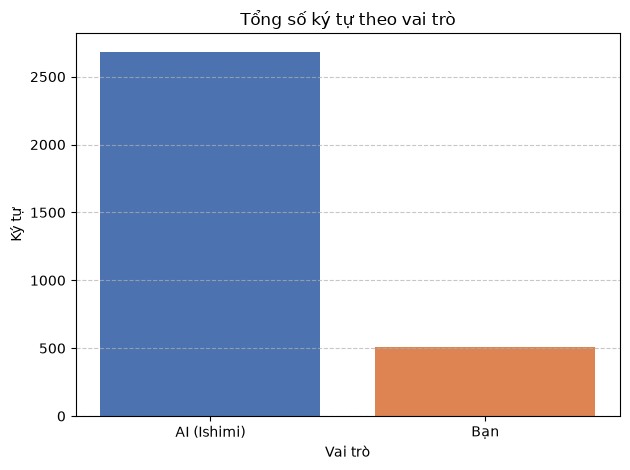

In [21]:
# Vẽ biểu đồ cột tổng số ký tự
plt.Figure(figsize=(8, 5))
plt.bar(x=summary.index.map(role_labels), height=summary["sum"],
        color=["#4C72B0", "#DD8452"])
plt.title("Tổng số ký tự theo vai trò")
plt.xlabel("Vai trò")
plt.ylabel("Ký tự")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

Text(0, 0.5, '')

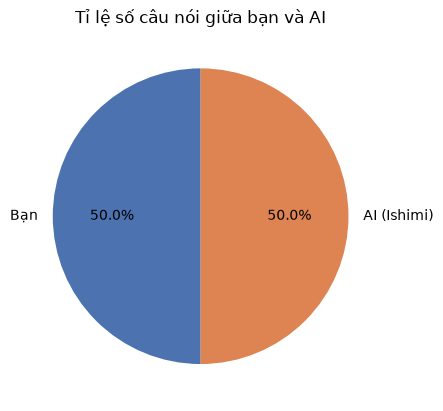

In [24]:
# Vẽ biểu đồ tròn: Tỉ lệ câu nói
plt.Figure(figsize=(6,6))
df['role_label'].value_counts().plot.pie(
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4C72B0", "#DD8452"]
)

plt.title("Tỉ lệ số câu nói giữa bạn và AI")
plt.ylabel("")

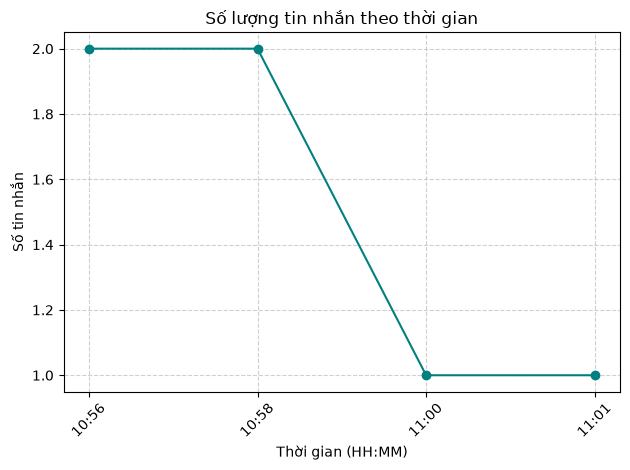

In [25]:
# Vẽ biểu đồ số tin nhắn theo thời gian
if "time" in df.columns:
    # Chuyển time sang datetime
    df['time'] = pd.to_datetime(df["time"])
    df = df.sort_values("time")
    
    # Tạo cột phút/giờ để đếm
    df["minute"] = df["time"].dt.strftime("%H:%M")
    
    # Số tin nhắn mỗi phút
    msg_per_min = df.groupby("minute").size()
    
    plt.Figure(figsize=(10, 5))
    plt.plot(msg_per_min.index, msg_per_min.values, marker="o", linestyle="-", color="teal")
    plt.title("Số lượng tin nhắn theo thời gian")
    plt.xlabel("Thời gian (HH:MM)")
    plt.ylabel("Số tin nhắn")
    plt.xticks(rotation=45)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()

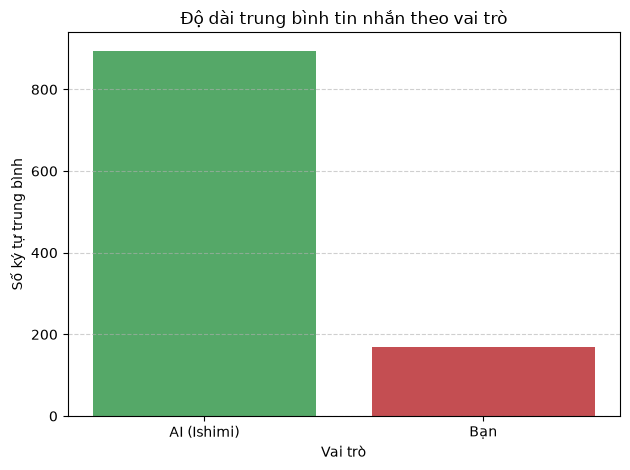

In [27]:
# Biểu độ cột: Độ dài tin nhắn trung bình theo vai trò
plt.Figure(figsize=(8, 5))
plt.bar(summary.index.map(role_labels), summary["mean"],
        color= ["#55A868", "#C44E52"])
plt.title("Độ dài trung bình tin nhắn theo vai trò")
plt.ylabel("Số ký tự trung bình")
plt.xlabel("Vai trò")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()